# EGVP Aftercourt Models & Automation

This notebook measures the automation rate of incoming **EGVP** court attachments.
Every *processed* attachment is scored by the EGVP aftercourt pipeline
(`__ATTACHMENTS_MODELS__["egvp"]` in the `intent_recognition` repo), which runs **7 models**
and writes their outputs to `llm_attachments_predictions`. A single aftercourt type then
"wins" per attachment by priority, and is only flagged `ready_for_automation` once its
required parameters are satisfied.

## Binary models (classical ML — TF-IDF + RandomForest, `AfterCourtClassificationModel`)

| Model | Aftercourt type | Key outputs | Notes |
|---|---|---|---|
| `aftercourt_classification_ladung` | `ladung_va` | `class_pred`, `class_prob`, `slug`, `debtor_name`, `judicial_summon_date` | RF classifier `18-02-2026_binary_ladung_rf_classifier_v1`; params via spaCy `de_core_news_md` NER + regex |
| `aftercourt_classification_pfub` | `pfub_erlass` | `class_pred`, `class_prob`, `slug`, `debtor_name`, `creditor_name` | RF classifier `12-01-2026_binary_pfub_rf_classifier_v1`; low-priority fallback only |

Both share TF-IDF vectorizer `05-12-2026_tf_idf_vectorizer_v1` (S3: `pair-email-classification/models/aftercourt_classification2`).

## LLM models (SGLang-served Qwen)

| Model | Backbone | Key outputs | Purpose |
|---|---|---|---|
| `pfub_erlass_egvp` | QwQ-32B | `is_pfub`, `is_invoice_inside`, `slug`, `debtor_name`, `creditor_name` | Confirm an *issued* Pfändungs- und Überweisungsbeschluss (PfÜB) |
| `drittauskunft_egvp` | Qwen3-4B | `is_dritt`, `is_invoice_inside`, `start_page`, `end_page` | Detect a Drittauskunft / §802l ZPO result payload |
| `vermogenverzeichnis_egvp` | Qwen3-4B | `is_va`, `is_invoice_inside`, `start_page`, `end_page` | Detect an actual Vermögensverzeichnis form |
| `invoice_detection_egvp` | QwQ-32B | `is_invoice_inside`, `start_page`, `end_page` | Locate an invoice / cost section inside a bundle |
| `egvp_standalone_invoice` | QwQ-32B | `invoice`, `reason`, `slug` | Strict single Gerichtsvollzieher payable-invoice classifier |

## Priority order (exactly one type wins per attachment)
1. **ladung_va** — `aftercourt_classification_ladung` (binary)
2. **pfub_erlass** — `pfub_erlass_egvp` (LLM), gated by `is_pfub`
3. **drittauskunft** — `drittauskunft_egvp` (LLM), gated by `is_dritt`
4. **vermogenverzeichnis** — `vermogenverzeichnis_egvp` (LLM), gated by `is_va`
5. **invoice** — `egvp_standalone_invoice` (LLM), gated by `invoice` + `reason == "must_pay"`

## Required params to count as automated (`ready_for_automation`)
- **ladung_va**: `slug`, `debtor_name`, `judicial_summon_date` all present
- **pfub_erlass**: `slug`, `debtor_name` present **and** `is_invoice_inside == False`
- **drittauskunft / vermogenverzeichnis**: `is_invoice_inside == False`
- **invoice**: `invoice == True` **and** `reason == "must_pay"`

> Source of truth: `src/graph/agents/agent_v1/logic/attachments_logic.py`
> (`get_prioritized_aftercourt_prediction`, `is_aftercourt_fully_automated`) and
> `src/shared/constants/aftercourt_required_params.py` (`AFTERCOURT_REQUIRED_PARAMS`).


In [2]:
import os
import json
from ast import literal_eval
from datetime import datetime, timedelta

import pandas as pd

import numpy as np
from IPython.display import clear_output

from python_utilities.db_connection import DbConnection


In [3]:
analytics_db = DbConnection('ANALYTICS', 'PROD_RDS')

INFO [2026-06-19 15:32:45] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file


In [4]:
# start and end is included
# start_date = "2026-05-01"
# end_date = "2026-05-06"
start_date = "2026-06-16"
end_date = "2026-06-19"

In [5]:
all_egvp_messages = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_tickets
    WHERE created_at >= '{start_date}'
    AND created_at < '{end_date}'
    AND source_type = 'egvp'
""")

In [6]:
print("Total messages:", len(all_egvp_messages))
print("Unique tickets:", all_egvp_messages['ticket_uuid'].nunique())
# ticket uuid is null
print("Messages with null ticket uuid:", all_egvp_messages['ticket_uuid'].isnull().sum())
print("Date max: {}, date min: {}".format(all_egvp_messages['created_at'].max(), all_egvp_messages['created_at'].min()))

Total messages: 1591
Unique tickets: 1591
Messages with null ticket uuid: 0
Date max: 2026-06-18 22:44:00, date min: 2026-06-16 05:44:00


### get attachments for egvp tickets -> basically the documents

In [7]:
egvp_attachments = analytics_db.sql_to_df(f"""
    SELECT la.*, lt.egvp_id
    FROM llm_attachments la
    LEFT JOIN llm_tickets lt
    ON la.ticket_uuid = lt.ticket_uuid
    WHERE la.created_at >= '{start_date}'
    AND la.created_at < '{end_date}'
""")

In [8]:
egvp_attachments

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id
0,3722852,4f176557-1504-58ed-95af-264d118ede3d,28197685693084-1,18853801.0,2.819769e+13,rejected_too_short,image001.jpg,jpg,2026-06-16 00:31:51,2026-06-16 00:01:13,ocr_source_files/2026-06-16/zendesk_id_1885380...,pair-data-engineering-new,None
1,3722853,ffd27bb5-ab3b-5b20-925d-c0554fa244b8,28197801109532-1,18853808.0,2.819780e+13,rejected_too_long,8611036193020265.pdf,pdf,2026-06-16 00:31:51,2026-06-16 00:13:11,ocr_source_files/2026-06-16/zendesk_id_1885380...,pair-data-engineering-new,None
2,3722854,f10d7dfb-ebe8-5dd9-85e4-eed9147a6593,28197878526748-1,18853811.0,2.819788e+13,rejected_too_short,qr_code_prefilled_payment_details.png,png,2026-06-16 00:51:53,2026-06-16 00:16:35,ocr_source_files/2026-06-16/zendesk_id_1885381...,pair-data-engineering-new,None
3,3722855,f10d7dfb-ebe8-5dd9-85e4-eed9147a6593,28197878526748-2,18853811.0,2.819788e+13,rejected_too_short,qr_code_prefilled_payment_details.png,png,2026-06-16 00:51:53,2026-06-16 00:16:35,ocr_source_files/2026-06-16/zendesk_id_1885381...,pair-data-engineering-new,None
4,3722856,f851e13d-9c88-5459-bf35-c5f8695a7827,28197834185500-1,18150025.0,2.819783e+13,processed,Screenshot+%2876%29.png,png,2026-06-16 01:20:22,2026-06-16 00:17:51,ocr_source_files/2026-06-16/zendesk_id_1815002...,pair-data-engineering-new,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17380,3740232,a85aa705-ffe1-5c60-ad62-97e331eeb403,28285986565148-1,18882288.0,2.828599e+13,processed,Juni+Kontoauszug+.pdf,pdf,2026-06-19 01:23:27,2026-06-18 23:33:10,ocr_source_files/2026-06-18/zendesk_id_1888228...,pair-data-engineering-new,None
17381,3740233,a85aa705-ffe1-5c60-ad62-97e331eeb403,28285986565148-2,18882288.0,2.828599e+13,processed,Nelly+Solutions+Rechnung+.pdf,pdf,2026-06-19 01:23:28,2026-06-18 23:33:10,ocr_source_files/2026-06-18/zendesk_id_1888228...,pair-data-engineering-new,None
17382,3740234,a8d66df5-3adb-5ccb-b0b6-c0c911dd1e90,28286009784220-1,18885768.0,2.828601e+13,processed,image.png,png,2026-06-19 01:23:32,2026-06-18 23:35:51,ocr_source_files/2026-06-18/zendesk_id_1888576...,pair-data-engineering-new,None
17383,3740235,79b01226-7785-56da-b9e8-27d13326c946,28286194075676-1,18885776.0,2.828619e+13,rejected_too_short,qr_code_prefilled_payment_details.png,png,2026-06-19 00:21:49,2026-06-18 23:54:18,ocr_source_files/2026-06-18/zendesk_id_1888577...,pair-data-engineering-new,None


### only get attachments from egvp

In [9]:
egvp_attachments = egvp_attachments[~egvp_attachments['attachment_id'].str.contains('-')]

In [10]:
egvp_attachments.ticket_uuid.nunique()

1591

###below should be true

In [11]:
egvp_attachments.ticket_uuid.dropna().unique().sort() == all_egvp_messages['ticket_uuid'].dropna().unique().sort()

True

# Automation percentage analysis

### 1) Incoming egvp attachment grouped by date

<Axes: title={'center': 'Daily Incoming EGVP Attachments'}, xlabel='created_at'>

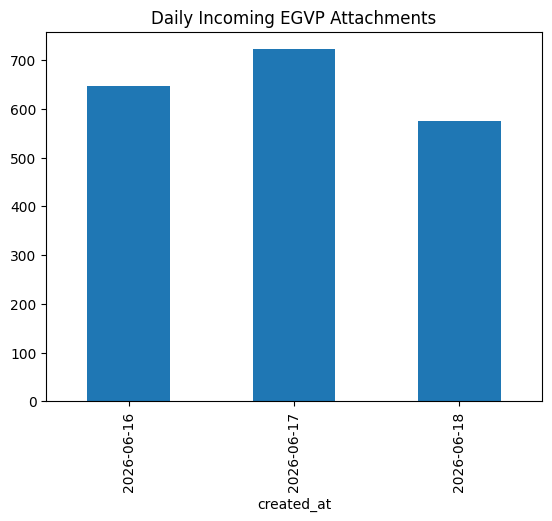

In [12]:
daily_incoming_egvp_attachments = egvp_attachments.groupby(egvp_attachments['created_at'].dt.date).size()
daily_incoming_egvp_attachments.plot(kind='bar', title='Daily Incoming EGVP Attachments')

### 2)Check statuses

In [13]:
import plotly.express as px

daily_status = (
    egvp_attachments
    .groupby([egvp_attachments['created_at'].dt.date, 'status'])
    .size()
    .reset_index(name='count')
    .rename(columns={'created_at': 'day'})
)
daily_status['day'] = daily_status['day'].astype(str)

fig = px.bar(
    daily_status,
    x='day',
    y='count',
    color='status',
    title='Daily Incoming EGVP Attachments by Status',
    labels={'day': 'Day', 'count': 'Count', 'status': 'Status'},
    text='count',
)
fig.update_layout(
    template='plotly_white',
    barmode='stack',
    width=1000,
    height=500,
    legend_title_text='',
)
fig.show()

### 3) Get Predictions for EGVP attachments

In [14]:
# get predictions for the corresponding attachments
print("Number of unique attachments:", egvp_attachments['attachment_id'].nunique())

Number of unique attachments: 1944


In [15]:
egvp_attachment_preds = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_attachments_predictions
    WHERE attachment_id IN ({', '.join([f"'{att_id}'" for att_id in egvp_attachments.attachment_id.unique()])})
""")

In [16]:
egvp_attachments.attachment_id.nunique()

1944

In [17]:
egvp_attachment_preds.attachment_id.nunique()

1841

In [18]:
print("Among {} unique attachments, {} have predictions.".format(
    egvp_attachments.attachment_id.nunique(),
    egvp_attachment_preds.attachment_id.nunique()
))

Among 1944 unique attachments, 1841 have predictions.


In [19]:
processed_atch_counts = egvp_attachments[egvp_attachments['status'] == 'processed'].shape[0]
print(egvp_attachment_preds.attachment_id.nunique()==processed_atch_counts) # should be true

True


In [20]:
# Reshape long-format predictions -> one row per attachment_id with
# columns like ladung_class_prob, ladung_slug, pfub_debtor_name, etc.

preds = egvp_attachment_preds.copy()

# strip stray single-quotes that wrap the stored values
preds['value'] = preds['value'].astype(str).str.replace("'", "", regex=False)

# build wide column name: "<short_model>_<subtype>"
preds['col'] = (
    preds['model_name'].str.replace('aftercourt_classification_', '', regex=False)
    + '_' + preds['subtype']
)

wide_attch_preds = (
    preds.pivot_table(
        index='attachment_id',
        columns='col',
        values='value',
        aggfunc='first',  # in case of duplicate (attachment_id, col)
    )
    .reset_index()
)
wide_attch_preds.columns.name = None

# cast probability columns to float and fill missing
prob_cols = [c for c in wide_attch_preds.columns if c.endswith('_class_prob')]
for c in prob_cols:
    wide_attch_preds[c] = pd.to_numeric(wide_attch_preds[c], errors='coerce').fillna(-1)

# fill remaining (string) columns with 'none'
str_cols = [c for c in wide_attch_preds.columns if c not in prob_cols + ['attachment_id']]
wide_attch_preds[str_cols] = wide_attch_preds[str_cols].fillna('none')

wide_attch_preds


,attachment_id,drittauskunft_egvp_end_page,drittauskunft_egvp_is_dritt,drittauskunft_egvp_is_invoice_inside,drittauskunft_egvp_start_page,egvp_standalone_invoice_invoice,egvp_standalone_invoice_reason,egvp_standalone_invoice_slug,invoice_detection_egvp_end_page,invoice_detection_egvp_is_invoice_inside,...,pfub_erlass_egvp_creditor_name,pfub_erlass_egvp_debtor_name,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,pfub_erlass_egvp_slug,pfub_slug,vermogenverzeichnis_egvp_end_page,vermogenverzeichnis_egvp_is_invoice_inside,vermogenverzeichnis_egvp_is_va,vermogenverzeichnis_egvp_start_page
0,68856476,1,True,True,1,False,multiple_docs,none,1,True,...,none,none,True,False,none,none,1,True,False,1
1,68856618,1,False,True,1,True,must_pay,none,1,True,...,none,none,True,False,none,none,1,True,False,1
2,68856630,-1,True,False,-1,False,multiple_docs,none,-1,False,...,none,none,False,False,none,none,-1,False,False,-1
3,68856633,-1,True,False,-1,False,multiple_docs,none,-1,False,...,none,none,False,False,none,none,-1,False,False,-1
4,68856639,-1,False,False,-1,False,not_invoice,none,-1,False,...,none,none,False,False,none,none,-1,False,False,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1836,69064288,1,False,True,1,False,multiple_docs,none,1,True,...,none,none,True,False,none,none,1,True,False,1
1837,69064289,-1,False,False,-1,True,must_pay,199254087752,-1,False,...,none,none,True,False,none,none,-1,False,False,-1
1838,69064290,-1,True,False,-1,False,not_invoice,none,-1,False,...,none,none,False,False,none,none,-1,False,False,-1
1839,69064293,-1,False,False,-1,False,not_invoice,none,-1,False,...,none,none,False,False,none,none,-1,False,False,-1


In [21]:
print(wide_attch_preds.attachment_id.nunique())

1841


### 4) Automation Calculation for EGVP attachments using preds

Per-attachment model outputs from `llm_attachments_predictions` are scored against the
**production aftercourt rules** (priority order + required-params gating). Exactly one
aftercourt type wins per attachment — **ladung_va** (binary), **pfub_erlass**,
**drittauskunft**, **vermogenverzeichnis** or **invoice** (LLM models) — mirroring what
the pipeline writes to `egvp_intents.ready_for_automation`. See the models overview at the
top of the notebook.


In [22]:
# ---------------------------------------------------------------------------
# Aftercourt automation rules (predictions-based)
#
# Mirrors the production logic in the intent_recognition repo:
#   * src/graph/agents/agent_v1/logic/attachments_logic.py
#         get_prioritized_aftercourt_prediction()  +  is_aftercourt_fully_automated()
#   * src/shared/constants/aftercourt_required_params.py  (AFTERCOURT_REQUIRED_PARAMS)
#
# Each processed EGVP attachment is scored by 7 models; exactly ONE aftercourt type
# wins, by this priority order:
#   1. ladung_va           -> aftercourt_classification_ladung  (binary TF-IDF + RandomForest)
#   2. pfub_erlass         -> pfub_erlass_egvp                   (LLM, QwQ-32B)
#   3. drittauskunft       -> drittauskunft_egvp                 (LLM, Qwen3-4B)
#   4. vermogenverzeichnis -> vermogenverzeichnis_egvp           (LLM, Qwen3-4B)
#   5. invoice             -> egvp_standalone_invoice            (LLM, QwQ-32B)
# ---------------------------------------------------------------------------

# probability threshold for accepting the ladung binary classifier as automatable
LADUNG_AUTOMATION_PROB_THRESHOLD = 0.95


def _is_true(value):
    """Normalise the stringified booleans stored in llm_attachments_predictions."""
    return value in (True, 'true', 'True', 1, '1')


def _is_present(value):
    """A parameter counts as extracted when it is a non-empty / non-'none' value."""
    return value not in (None, '', 'none', 'None', -1, '-1')


def _to_float(value, default=-1.0):
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def is_all_params_extracted_ladung(slug, debtor_name, judicial_summon_date):
    return _is_present(slug) and _is_present(debtor_name) and _is_present(judicial_summon_date)


def is_all_params_extracted_pfub(slug, debtor_name):
    return _is_present(slug) and _is_present(debtor_name)


def is_automated_ladung(row):
    # ladung_va: binary classifier confident + slug / debtor_name / summon_date extracted
    is_ladung = _to_float(row.get('ladung_class_prob', -1)) >= LADUNG_AUTOMATION_PROB_THRESHOLD
    return is_ladung and is_all_params_extracted_ladung(
        row.get('ladung_slug'),
        row.get('ladung_debtor_name'),
        row.get('ladung_judicial_summon_date'),
    )


def is_automated_pfub(row):
    # pfub_erlass: LLM says is_pfub, slug + debtor_name extracted, and no invoice inside
    is_pfub = _is_true(row.get('pfub_erlass_egvp_is_pfub'))
    is_invoice_inside = _is_true(row.get('pfub_erlass_egvp_is_invoice_inside'))
    return (
        is_pfub
        and is_all_params_extracted_pfub(
            row.get('pfub_erlass_egvp_slug'),
            row.get('pfub_erlass_egvp_debtor_name'),
        )
        and not is_invoice_inside
    )


def is_automated_dritt(row):
    # drittauskunft: LLM says is_dritt and no invoice inside
    return _is_true(row.get('drittauskunft_egvp_is_dritt')) and not _is_true(
        row.get('drittauskunft_egvp_is_invoice_inside')
    )


def is_automated_va(row):
    # vermogenverzeichnis: LLM says is_va and no invoice inside
    return _is_true(row.get('vermogenverzeichnis_egvp_is_va')) and not _is_true(
        row.get('vermogenverzeichnis_egvp_is_invoice_inside')
    )


def is_automated_invoice(row):
    # standalone invoice: LLM says invoice and reason == 'must_pay'
    return _is_true(row.get('egvp_standalone_invoice_invoice')) and (
        row.get('egvp_standalone_invoice_reason') == 'must_pay'
    )


def get_automated_aftercourt_type(row):
    """Return the single aftercourt type an attachment is automated as (priority order), else 'none'."""
    if is_automated_ladung(row):
        return 'ladung_va'
    if is_automated_pfub(row):
        return 'pfub_erlass'
    if is_automated_dritt(row):
        return 'drittauskunft'
    if is_automated_va(row):
        return 'vermogenverzeichnis'
    if is_automated_invoice(row):
        return 'invoice'
    return 'none'


In [23]:
wide_attch_preds

,attachment_id,drittauskunft_egvp_end_page,drittauskunft_egvp_is_dritt,drittauskunft_egvp_is_invoice_inside,drittauskunft_egvp_start_page,egvp_standalone_invoice_invoice,egvp_standalone_invoice_reason,egvp_standalone_invoice_slug,invoice_detection_egvp_end_page,invoice_detection_egvp_is_invoice_inside,...,pfub_erlass_egvp_creditor_name,pfub_erlass_egvp_debtor_name,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,pfub_erlass_egvp_slug,pfub_slug,vermogenverzeichnis_egvp_end_page,vermogenverzeichnis_egvp_is_invoice_inside,vermogenverzeichnis_egvp_is_va,vermogenverzeichnis_egvp_start_page
0,68856476,1,True,True,1,False,multiple_docs,none,1,True,...,none,none,True,False,none,none,1,True,False,1
1,68856618,1,False,True,1,True,must_pay,none,1,True,...,none,none,True,False,none,none,1,True,False,1
2,68856630,-1,True,False,-1,False,multiple_docs,none,-1,False,...,none,none,False,False,none,none,-1,False,False,-1
3,68856633,-1,True,False,-1,False,multiple_docs,none,-1,False,...,none,none,False,False,none,none,-1,False,False,-1
4,68856639,-1,False,False,-1,False,not_invoice,none,-1,False,...,none,none,False,False,none,none,-1,False,False,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1836,69064288,1,False,True,1,False,multiple_docs,none,1,True,...,none,none,True,False,none,none,1,True,False,1
1837,69064289,-1,False,False,-1,True,must_pay,199254087752,-1,False,...,none,none,True,False,none,none,-1,False,False,-1
1838,69064290,-1,True,False,-1,False,not_invoice,none,-1,False,...,none,none,False,False,none,none,-1,False,False,-1
1839,69064293,-1,False,False,-1,False,not_invoice,none,-1,False,...,none,none,False,False,none,none,-1,False,False,-1


In [24]:
# resolve the single winning aftercourt type per attachment (priority order),
# then derive per-type boolean flags so every attachment is counted at most once
wide_attch_preds['automated_type'] = wide_attch_preds.apply(get_automated_aftercourt_type, axis=1)

wide_attch_preds['is_automated_ladung'] = wide_attch_preds['automated_type'] == 'ladung_va'
wide_attch_preds['is_automated_pfub'] = wide_attch_preds['automated_type'] == 'pfub_erlass'
wide_attch_preds['is_automated_dritt'] = wide_attch_preds['automated_type'] == 'drittauskunft'
wide_attch_preds['is_automated_va'] = wide_attch_preds['automated_type'] == 'vermogenverzeichnis'
wide_attch_preds['is_automated_invoice'] = wide_attch_preds['automated_type'] == 'invoice'


In [25]:
# add dates to wide_attch_preds by merging with egvp_attachments
wide_attch_preds = (wide_attch_preds
    .merge(
        egvp_attachments[['attachment_id', 'created_at']],
        on='attachment_id',
        how='left'
    )
)

In [26]:
daily_incoming_egvp_attachments = egvp_attachments.groupby(egvp_attachments['created_at'].dt.date).size()
daily_automated_ladung = (
    wide_attch_preds[wide_attch_preds['is_automated_ladung']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)
daily_automated_pfub = (
    wide_attch_preds[wide_attch_preds['is_automated_pfub']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)
daily_automated_dritt = (
    wide_attch_preds[wide_attch_preds['is_automated_dritt']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)
daily_automated_va = (
    wide_attch_preds[wide_attch_preds['is_automated_va']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)
daily_automated_invoice = (
    wide_attch_preds[wide_attch_preds['is_automated_invoice']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)


In [27]:
daily_incoming_egvp_rejected_attachments = (
    egvp_attachments[egvp_attachments['status'] == 'rejected_too_long']
    .groupby(egvp_attachments['created_at'].dt.date)
    .size()
)
daily_incoming_egvp_rejected_attachments

created_at
2026-06-16    37
2026-06-17    31
2026-06-18    35
dtype: int64

In [28]:
# Daily automation rate (%) per aftercourt type vs total incoming attachments
daily_df = (
    pd.concat(
        [
            daily_incoming_egvp_attachments.rename('total'),
            daily_incoming_egvp_rejected_attachments.rename('rejected'),
            daily_automated_ladung.rename('ladung'),
            daily_automated_pfub.rename('pfub'),
            daily_automated_dritt.rename('dritt'),
            daily_automated_va.rename('va'),
            daily_automated_invoice.rename('invoice'),
        ],
        axis=1,
    )
    .fillna(0)
    .sort_index()
)
daily_df.index = pd.to_datetime(daily_df.index)
daily_df.index.name = 'day'
for _c in ['ladung', 'pfub', 'dritt', 'va', 'invoice', 'rejected']:
    daily_df[f'{_c}_pct'] = (daily_df[_c] / daily_df['total'] * 100).round(2)

plot_df = daily_df.reset_index()

y_cols = ['ladung_pct', 'pfub_pct', 'dritt_pct', 'va_pct', 'invoice_pct', 'rejected_pct']
abs_cols = {
    'ladung_pct': 'ladung',
    'pfub_pct': 'pfub',
    'dritt_pct': 'dritt',
    'va_pct': 'va',
    'invoice_pct': 'invoice',
    'rejected_pct': 'rejected',
}
labels_map = {
    'ladung_pct': 'LADUNG (binary)',
    'pfub_pct': 'PFUB (LLM)',
    'dritt_pct': 'DRITT (LLM)',
    'va_pct': 'VA (LLM)',
    'invoice_pct': 'INVOICE (LLM)',
    'rejected_pct': 'REJECTED (too long)',
}

fig = px.line(
    plot_df,
    x='day',
    y=y_cols,
    markers=True,
    title='Daily Automation Rate by Aftercourt Type (predictions) — Ladung / PFUB / Dritt / VA / Invoice',
    labels={'day': 'Day', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map={
        'ladung_pct': '#1f77b4',
        'pfub_pct': '#ff7f0e',
        'dritt_pct': '#9467bd',
        'va_pct': '#2ca02c',
        'invoice_pct': '#8c564b',
        'rejected_pct': '#d62728',
    },
)

# add absolute counts as hover info; dash the rejected line to distinguish it
for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [daily_df[abs_col].values, daily_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>%{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Count: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )
    if col == 'rejected_pct':
        trace.line.dash = 'dash'

# rename legend entries
fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1000,
    height=500,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9), selector=dict(mode='lines+markers'))
fig.show()


In [29]:
total_mean = daily_df['total'].mean()
ladung_auto_mean = daily_df['ladung'].mean()
pfub_auto_mean = daily_df['pfub'].mean()
dritt_auto_mean = daily_df['dritt'].mean()
va_auto_mean = daily_df['va'].mean()
invoice_auto_mean = daily_df['invoice'].mean()
overall_auto_mean = ladung_auto_mean + pfub_auto_mean + dritt_auto_mean + va_auto_mean + invoice_auto_mean


def _pct(part, whole):
    return (part / whole * 100) if whole > 0 else 0


print("Average daily incoming attachments: {:.2f}".format(total_mean))
print("Average daily automated Ladung: {:.2f} ({:.2f}%)".format(ladung_auto_mean, _pct(ladung_auto_mean, total_mean)))
print("Average daily automated PFUB: {:.2f} ({:.2f}%)".format(pfub_auto_mean, _pct(pfub_auto_mean, total_mean)))
print("Average daily automated Dritt: {:.2f} ({:.2f}%)".format(dritt_auto_mean, _pct(dritt_auto_mean, total_mean)))
print("Average daily automated VA: {:.2f} ({:.2f}%)".format(va_auto_mean, _pct(va_auto_mean, total_mean)))
print("Average daily automated Invoice: {:.2f} ({:.2f}%)".format(invoice_auto_mean, _pct(invoice_auto_mean, total_mean)))
print("Overall average daily automation rate: {:.2f}%".format(_pct(overall_auto_mean, total_mean)))


Average daily incoming attachments: 648.00
Average daily automated Ladung: 89.67 (13.84%)
Average daily automated PFUB: 81.67 (12.60%)
Average daily automated Dritt: 64.67 (9.98%)
Average daily automated VA: 8.00 (1.23%)
Average daily automated Invoice: 128.00 (19.75%)
Overall average daily automation rate: 57.41%


In [30]:
total_incoming = daily_df['total'].sum()
ladung_auto_total = daily_df['ladung'].sum()
pfub_auto_total = daily_df['pfub'].sum()
dritt_auto_total = daily_df['dritt'].sum()
va_auto_total = daily_df['va'].sum()
invoice_auto_total = daily_df['invoice'].sum()
overall_auto_total = ladung_auto_total + pfub_auto_total + dritt_auto_total + va_auto_total + invoice_auto_total


def _pct_total(part):
    return (part / total_incoming * 100) if total_incoming > 0 else 0


print("Total incoming attachments: {:.0f}".format(total_incoming))
print("Total automated Ladung: {:.0f} ({:.2f}%)".format(ladung_auto_total, _pct_total(ladung_auto_total)))
print("Total automated PFUB: {:.0f} ({:.2f}%)".format(pfub_auto_total, _pct_total(pfub_auto_total)))
print("Total automated Dritt: {:.0f} ({:.2f}%)".format(dritt_auto_total, _pct_total(dritt_auto_total)))
print("Total automated VA: {:.0f} ({:.2f}%)".format(va_auto_total, _pct_total(va_auto_total)))
print("Total automated Invoice: {:.0f} ({:.2f}%)".format(invoice_auto_total, _pct_total(invoice_auto_total)))
print("Overall total automation rate: {:.2f}%".format(_pct_total(overall_auto_total)))


Total incoming attachments: 1944
Total automated Ladung: 269 (13.84%)
Total automated PFUB: 245 (12.60%)
Total automated Dritt: 194 (9.98%)
Total automated VA: 24 (1.23%)
Total automated Invoice: 384 (19.75%)
Overall total automation rate: 57.41%


### 5) Automation Calculation using egvp intents table

In [31]:
egvp_intents = analytics_db.sql_to_df(f"""
    SELECT *
    FROM egvp_intents
    WHERE created_at >= '{start_date}'
    AND created_at <= '{end_date}'
    AND attachment_id IN ({', '.join([f"'{att_id}'" for att_id in egvp_attachments.attachment_id.unique()])})
""")


In [32]:
total_found_intents = len(egvp_intents)
total_attachments_given_dates = egvp_attachments['attachment_id'].nunique()
total_processed_attachments = egvp_attachments[egvp_attachments['status'] == 'processed']['attachment_id'].nunique()
total_rejected_attachments = egvp_attachments[egvp_attachments['status'] == 'rejected_too_long']['attachment_id'].nunique()
print("Total found intents: {}, total attachments given dates: {}, total processed attachments: {}, total rejected attachments: {}".format(
    total_found_intents,
    total_attachments_given_dates,
    total_processed_attachments,
    total_rejected_attachments
))

Total found intents: 1943, total attachments given dates: 1944, total processed attachments: 1841, total rejected attachments: 103


In [33]:
egvp_intents['attachment_id'] = egvp_intents['attachment_id'].astype(str)

In [34]:
intent_cant_found_attachment_ids = set(egvp_attachments['attachment_id'].unique()) - set(egvp_intents['attachment_id'].unique())

In [35]:
print("Total intents:", len(egvp_intents))
print("Unique attachments in intents:", egvp_intents['attachment_id'].nunique())
print("Intents can't found for {} attachments.".format(len(intent_cant_found_attachment_ids)))

Total intents: 1943
Unique attachments in intents: 1943
Intents can't found for 1 attachments.


In [36]:
automation_from_intents_db = egvp_attachments.merge(
    egvp_intents[['attachment_id', 'intents','ready_for_automation']],
    on='attachment_id',
    how='left'
)

In [37]:
def find_how_automated(row):
    intent = row['intents']
    if intent:
        try:
            intent = intent.lower()
        except:
            return "none"
        if "ladung_va" in intent:
            return "ladung_va"
        elif "pfub_erlass" in intent:
            return "pfub_erlass"
        elif "vermogen" in intent:
            return "va"
        elif "dritt" in intent:
            return "dritt"
        elif '"aftercourt_type": "invoice"' in intent:
            return "invoice"
        else:
            return "none"
    else:
        return "none"
        

automation_from_intents_db['how_automated'] = automation_from_intents_db.apply(lambda row: find_how_automated(row) if row['ready_for_automation'] else 'none', axis=1)

In [38]:
automation_from_intents_db['how_automated'].value_counts()

how_automated
none           839
invoice        375
ladung_va      268
pfub_erlass    245
dritt          193
va              24
Name: count, dtype: int64

In [49]:
check = automation_from_intents_db[automation_from_intents_db['how_automated']=="va"]
check

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id,intents,ready_for_automation,how_automated
11,3723122,d626c590-3d82-562f-a573-48e033e4e495,68856650,NaN,NaN,processed,68856650_eintrag.pdf,pdf,2026-06-16 06:42:09,2026-06-16 05:44:00,ocr_source_files/2026-06-16/egvp_id_389009/688...,pair-data-engineering-new,NRW_B21781585502725bd87534a-8aea-404f-bf56-de7...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
84,3724442,ef8369d0-a253-5e9e-8716-c56d64257475,68860450,NaN,NaN,processed,68860450_VAK_Celebi-signed.pdf,pdf,2026-06-16 09:37:16,2026-06-16 08:44:00,ocr_source_files/2026-06-16/egvp_id_389100/688...,pair-data-engineering-new,NRW_B21781594106009dff094fa-7829-46bb-9da3-65f...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
151,3724949,6a90f704-a47e-5984-9efa-2ea83c5ae3e3,68863343,NaN,NaN,processed,68863343_Vermoegensverzeichnis_zu_DRII-065126.pdf,pdf,2026-06-16 14:26:01,2026-06-16 09:44:00,ocr_source_files/2026-06-16/egvp_id_389194/688...,pair-data-engineering-new,NRW_B21781598079718f11abdba-fdce-432b-a36a-1ea...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
237,3725599,da19d623-55a1-5afd-b272-da832af91c3f,68865053,NaN,NaN,processed,68865053_VV_84425.pdf,pdf,2026-06-16 14:33:10,2026-06-16 10:44:00,ocr_source_files/2026-06-16/egvp_id_389291/688...,pair-data-engineering-new,NRW_B21781603214212294240fd-6a50-4668-a355-15a...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
278,3726120,d583aad4-a831-5d09-b356-60738a677f78,68867019,NaN,NaN,processed,68867019_Vermoegensverzeichnis_zu_DRII-055926_...,pdf,2026-06-16 14:35:04,2026-06-16 11:44:00,ocr_source_files/2026-06-16/egvp_id_389352/688...,pair-data-engineering-new,NRW_B21781605052527281d2e39-0655-4f40-8f2c-230...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
291,3726133,ae424b16-0671-5e04-9ac7-2adba0f4e629,68867063,NaN,NaN,processed,68867063_Vermoegensverzeichnis_zu_DRII-058724-...,pdf,2026-06-16 14:35:38,2026-06-16 11:44:00,ocr_source_files/2026-06-16/egvp_id_389363/688...,pair-data-engineering-new,NRW_B217816065504292172c796-03a3-491c-ba3d-36d...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
549,3727867,a59d87be-5a6f-5cf6-b8c2-e298af1f53ed,68870743,NaN,NaN,processed,68870743_vvz.pdf,pdf,2026-06-16 17:24:30,2026-06-16 15:44:00,ocr_source_files/2026-06-16/egvp_id_389722/688...,pair-data-engineering-new,NRW_B21781618558554b8737309-512a-4343-87b9-041...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
608,3728415,62d2b946-3317-5a4f-9374-4085f6cf2679,68872220,NaN,NaN,processed,68872220_Vermoegensverzeichnis_zu_DRII-071326.pdf,pdf,2026-06-16 19:40:29,2026-06-16 18:44:00,ocr_source_files/2026-06-16/egvp_id_389788/688...,pair-data-engineering-new,NRW_B2178163157943287556134-9d9e-4e39-a9b1-0c7...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
680,3729372,8fb6f523-8d61-5633-8533-801ade95a5ef,68987685,NaN,NaN,processed,68987685_53726Arnold.pdf,pdf,2026-06-17 10:30:45,2026-06-17 06:44:00,ocr_source_files/2026-06-17/egvp_id_389859/689...,pair-data-engineering-new,NRW_B21781675936382d2e571af-b8d0-4e78-8b1d-f1f...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
725,3730353,7bc72b90-620c-52cc-b0eb-c5bcf2ba78c4,68991360,NaN,NaN,processed,68991360_Vermoegensverzeichnis_zu_DRII-027826.pdf,pdf,2026-06-17 10:31:38,2026-06-17 08:44:00,ocr_source_files/2026-06-17/egvp_id_390052/689...,pair-data-engineering-new,NRW_B21781682510438491a0cfc-e214-4ca3-9b58-f72...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va


In [50]:
check.egvp_id.unique()

array(['NRW_B21781585502725bd87534a-8aea-404f-bf56-de77e83b65cb',
       'NRW_B21781594106009dff094fa-7829-46bb-9da3-65fde11641f0',
       'NRW_B21781598079718f11abdba-fdce-432b-a36a-1ea510daebcf',
       'NRW_B21781603214212294240fd-6a50-4668-a355-15a0dbe2e38a',
       'NRW_B21781605052527281d2e39-0655-4f40-8f2c-2306ac145f29',
       'NRW_B217816065504292172c796-03a3-491c-ba3d-36d516e70dab',
       'NRW_B21781618558554b8737309-512a-4343-87b9-04127d051993',
       'NRW_B2178163157943287556134-9d9e-4e39-a9b1-0c7e370aa6dc',
       'NRW_B21781675936382d2e571af-b8d0-4e78-8b1d-f1f493b7a139',
       'NRW_B21781682510438491a0cfc-e214-4ca3-9b58-f726548e5b39',
       'NRW_B2178169186233013981e8c-e541-47b6-9c71-4369065e03fc',
       'NRW_B21781695051864fcf84520-1e45-419a-b475-da7f9658dec6',
       'NRW_B2178170083921809304bfc-e615-4b8d-9fd7-1752727db8e8',
       'NRW_B21781701172600034f0db6-fd54-4436-a9e2-1f89e1cba432',
       'NRW_B21781703388157ca8a9f96-edc2-430b-a46d-6d6bb751a2ab',
       'NR

In [39]:
automation_from_intents_db

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id,intents,ready_for_automation,how_automated
0,3723111,6c1f49f3-fba0-5793-b3d6-e35bbedc1461,68856476,NaN,NaN,processed,68856476_DR_II_702_26_An_Gl_HBAntrag_NICHT_ERS...,pdf,2026-06-16 06:41:53,2026-06-16 05:44:00,ocr_source_files/2026-06-16/egvp_id_389003/688...,pair-data-engineering-new,NRW_B217815841855076005cc33-e8b6-4d80-ba17-d72...,"[{""params"": {""end_page"": 1, ""start_page"": 1, ""...",0.0,none
1,3723112,d64e9e7a-1d55-55c4-adaf-3e1139e4ab9c,68856618,NaN,NaN,processed,68856618_Dokument_26926_15062026_201913.pdf,pdf,2026-06-16 06:42:01,2026-06-16 05:44:00,ocr_source_files/2026-06-16/egvp_id_389004/688...,pair-data-engineering-new,NRW_B2178158368571239f902c5-3ec7-4fb7-b7ef-31a...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",1.0,invoice
2,3723113,48b9f547-0718-5d90-85e4-789efbf5ea39,68856630,NaN,NaN,processed,68856630_DA.pdf,pdf,2026-06-16 06:41:58,2026-06-16 05:44:00,ocr_source_files/2026-06-16/egvp_id_389005/688...,pair-data-engineering-new,NRW_B21781584149137412ea9ba-0dfe-4d7d-b249-94d...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,dritt
3,3723114,982aea25-03e2-542e-833f-49021904b846,68856633,NaN,NaN,processed,68856633_DA.pdf,pdf,2026-06-16 06:41:55,2026-06-16 05:44:00,ocr_source_files/2026-06-16/egvp_id_389006/688...,pair-data-engineering-new,NRW_B21781584145185e7f06016-17ec-4baa-bc3d-e2d...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,dritt
4,3723115,cdd538b2-f22e-5890-a08b-9c3350991dca,68856636,NaN,NaN,rejected_too_long,68856636_0_Sammel1.pdf,pdf,2026-06-16 06:13:03,2026-06-16 05:44:00,ocr_source_files/2026-06-16/egvp_id_389007/688...,pair-data-engineering-new,NRW_B21781582571107b5880528-d84c-4249-a595-e74...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1939,3740188,6cfeb898-3d65-54ac-8389-d98e19297a3c,69064288,NaN,NaN,processed,69064288_DR-II_068826_Nachr_Abschr__Protok__k_...,pdf,2026-06-18 22:55:34,2026-06-18 21:44:00,ocr_source_files/2026-06-18/egvp_id_392305/690...,pair-data-engineering-new,NRW_B21781812969048ec698b43-bb9c-41eb-a88d-37b...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
1940,3740189,6cfeb898-3d65-54ac-8389-d98e19297a3c,69064289,NaN,NaN,processed,69064289_DR-II_068826_Nachr_Protokoll_VAK-T___...,pdf,2026-06-18 22:55:35,2026-06-18 21:44:00,ocr_source_files/2026-06-18/egvp_id_392305/690...,pair-data-engineering-new,NRW_B21781812969048ec698b43-bb9c-41eb-a88d-37b...,"[{""params"": {""slug"": ""199254087752""}, ""channel...",1.0,invoice
1941,3740190,6cfeb898-3d65-54ac-8389-d98e19297a3c,69064290,NaN,NaN,processed,69064290_Ergebnis_BZST_geschwaerzt-signed.pdf,pdf,2026-06-18 22:55:31,2026-06-18 21:44:00,ocr_source_files/2026-06-18/egvp_id_392305/690...,pair-data-engineering-new,NRW_B21781812969048ec698b43-bb9c-41eb-a88d-37b...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,dritt
1942,3740191,0f8dd401-5395-5265-aa6a-4c841c0a5545,69064293,NaN,NaN,processed,69064293_DR_II_780_26_An_Gl_Terminsmitteilung_...,pdf,2026-06-18 22:55:37,2026-06-18 21:44:00,ocr_source_files/2026-06-18/egvp_id_392306/690...,pair-data-engineering-new,NRW_B2178181329755830e2a543-7630-4c68-b9b4-17a...,"[{""params"": {""slug"": ""196871544637"", ""debtor_n...",1.0,ladung_va


In [40]:
daily_incoming_egvp_attachments = automation_from_intents_db.groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_ladung_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'ladung_va'].groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_pfub_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'pfub_erlass'].groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_va_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'va'].groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_dritt_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'dritt'].groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_invoice_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'invoice'].groupby(automation_from_intents_db['created_at'].dt.date).size()

### plot graph

In [41]:
# Daily automation rate (%) for ladung, pfub, va, dritt and invoice from egvp_intents table
daily_intents_df = (
    pd.concat(
        [
            daily_incoming_egvp_attachments.rename('total'),
            daily_automated_ladung_from_egvp_intets.rename('ladung'),
            daily_automated_pfub_from_egvp_intets.rename('pfub'),
            daily_automated_va_from_egvp_intets.rename('va'),
            daily_automated_dritt_from_egvp_intets.rename('dritt'),
            daily_automated_invoice_from_egvp_intets.rename('invoice'),
        ],
        axis=1,
    )
    .fillna(0)
    .sort_index()
)
daily_intents_df.index = pd.to_datetime(daily_intents_df.index)
daily_intents_df.index.name = 'day'
daily_intents_df['ladung_pct'] = (daily_intents_df['ladung'] / daily_intents_df['total'] * 100).round(2)
daily_intents_df['pfub_pct'] = (daily_intents_df['pfub'] / daily_intents_df['total'] * 100).round(2)
daily_intents_df['va_pct'] = (daily_intents_df['va'] / daily_intents_df['total'] * 100).round(2)
daily_intents_df['dritt_pct'] = (daily_intents_df['dritt'] / daily_intents_df['total'] * 100).round(2)
daily_intents_df['invoice_pct'] = (daily_intents_df['invoice'] / daily_intents_df['total'] * 100).round(2)

plot_df = daily_intents_df.reset_index()

y_cols = ['ladung_pct', 'pfub_pct', 'va_pct', 'dritt_pct', 'invoice_pct']
abs_cols = {'ladung_pct': 'ladung', 'pfub_pct': 'pfub', 'va_pct': 'va', 'dritt_pct': 'dritt', 'invoice_pct': 'invoice'}
labels_map = {
    'ladung_pct': 'LADUNG (ladung_va)',
    'pfub_pct': 'PFUB (pfub_erlass)',
    'va_pct': 'VA (vermogen)',
    'dritt_pct': 'DRITT (dritt)',
    'invoice_pct': 'INVOICE (invoice)',
}

fig = px.line(
    plot_df,
    x='day',
    y=y_cols,
    markers=True,
    title='Daily Automation Rate from EGVP Intents — Ladung vs PFUB vs VA vs Dritt vs Invoice',
    labels={'day': 'Day', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map={
        'ladung_pct': '#1f77b4',
        'pfub_pct': '#ff7f0e',
        'va_pct': '#2ca02c',
        'dritt_pct': '#9467bd',
        'invoice_pct': '#d62728',
    },
)

for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [daily_intents_df[abs_col].values, daily_intents_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>%{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Automated: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )

fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1000,
    height=500,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9))
fig.show()

# Combine automation calculation using preds and egvp intents

Cross-check the two independent automation measurements for **every aftercourt type**
(ladung, pfub, dritt, va, invoice):

- **preds** — recomputed locally from `llm_attachments_predictions` using the production
  rules (section 4).
- **intents** — read straight from `egvp_intents.ready_for_automation` (section 5).

In the chart each aftercourt type keeps one colour; **solid = preds**, **dashed = intents**.
Large gaps between the solid and dashed line of the same colour flag a mismatch between the
locally reproduced rules and what the pipeline actually persisted.


In [42]:
# Combined: daily automation rate (%) from predictions vs egvp_intents table,
# for every aftercourt type. Same hue per type, solid = predictions, dashed = egvp_intents.
# NOTE: `daily_incoming_egvp_attachments` was overwritten in section 5 with the
# intents-merged frame (same totals per day, just rebuilt). Use it as the shared denominator.

# per aftercourt type: (preds daily series, egvp_intents daily series, colour)
combined_sources = {
    'ladung':  (daily_automated_ladung,  daily_automated_ladung_from_egvp_intets,  '#1f77b4'),
    'pfub':    (daily_automated_pfub,    daily_automated_pfub_from_egvp_intets,    '#ff7f0e'),
    'dritt':   (daily_automated_dritt,   daily_automated_dritt_from_egvp_intets,   '#9467bd'),
    'va':      (daily_automated_va,      daily_automated_va_from_egvp_intets,      '#2ca02c'),
    'invoice': (daily_automated_invoice, daily_automated_invoice_from_egvp_intets, '#8c564b'),
}

# stack the shared total + each type's two source series into one frame
series_list = [daily_incoming_egvp_attachments.rename('total')]
for _type, (_preds_series, _intents_series, _colour) in combined_sources.items():
    series_list.append(_preds_series.rename(f'{_type}_preds'))
    series_list.append(_intents_series.rename(f'{_type}_intents'))

combined_df = pd.concat(series_list, axis=1).fillna(0).sort_index()
combined_df.index = pd.to_datetime(combined_df.index)
combined_df.index.name = 'day'

# build percentage columns + plot metadata, looping type x source
y_cols, abs_cols, labels_map, color_map, dash_map = [], {}, {}, {}, {}
for _type, (_preds_series, _intents_series, _colour) in combined_sources.items():
    for _source in ('preds', 'intents'):
        abs_col = f'{_type}_{_source}'
        pct_col = f'{abs_col}_pct'
        combined_df[pct_col] = (combined_df[abs_col] / combined_df['total'] * 100).round(2)
        y_cols.append(pct_col)
        abs_cols[pct_col] = abs_col
        labels_map[pct_col] = f'{_type.upper()} ({_source})'
        color_map[pct_col] = _colour
        dash_map[pct_col] = 'solid' if _source == 'preds' else 'dash'

plot_df = combined_df.reset_index()

fig = px.line(
    plot_df,
    x='day',
    y=y_cols,
    markers=True,
    title='Daily Automation Rate — Predictions vs EGVP Intents (all aftercourt types)',
    labels={'day': 'Day', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map=color_map,
)

for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [combined_df[abs_col].values, combined_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>%{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Automated: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )
    trace.line.dash = dash_map[col]

fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1100,
    height=550,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9))
fig.show()


In [43]:
# Reconciliation: total automated per aftercourt type — predictions vs egvp_intents
total_incoming_combined = combined_df['total'].sum()

recon = pd.DataFrame(
    {
        'preds': {t: combined_df[f'{t}_preds'].sum() for t in combined_sources},
        'intents': {t: combined_df[f'{t}_intents'].sum() for t in combined_sources},
    }
)
recon.loc['ALL'] = recon.sum()  # totals across all types (preds / intents columns)
recon.index.name = 'aftercourt_type'

recon['diff_preds_minus_intents'] = recon['preds'] - recon['intents']
recon['preds_pct'] = (recon['preds'] / total_incoming_combined * 100).round(2)
recon['intents_pct'] = (recon['intents'] / total_incoming_combined * 100).round(2)

print("Analysis period: {} to {}".format(start_date, end_date))
print("Total incoming attachments: {:.0f}".format(total_incoming_combined))
print("Overall automation — preds: {:.2f}% | intents: {:.2f}%".format(
    recon.loc['ALL', 'preds_pct'], recon.loc['ALL', 'intents_pct']
))
recon


Analysis period: 2026-06-16 to 2026-06-19
Total incoming attachments: 1944
Overall automation — preds: 57.41% | intents: 56.84%


,preds,intents,diff_preds_minus_intents,preds_pct,intents_pct
aftercourt_type,,,,,
ladung,269,268,1,13.84,13.79
pfub,245,245,0,12.60,12.60
dritt,194,193,1,9.98,9.93
va,24,24,0,1.23,1.23
invoice,384,375,9,19.75,19.29
ALL,1116,1105,11,57.41,56.84


# One query to egvp intents to calculate automation

In [44]:
query = f"""
SELECT
    DATE(la.created_at) AS day,
    COUNT(DISTINCT la.attachment_id) AS total_incoming,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%ladung_va%%'
        THEN la.attachment_id
    END) AS ladung_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%pfub_erlass%%'
        THEN la.attachment_id
    END) AS pfub_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%vermogen%%'
        THEN la.attachment_id
    END) AS va_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%dritt%%'
        THEN la.attachment_id
    END) AS dritt_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%"aftercourt_type": "invoice"%%'
        THEN la.attachment_id
    END) AS invoice_automated,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%ladung_va%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS ladung_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%pfub_erlass%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS pfub_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%vermogen%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS va_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%dritt%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS dritt_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%"aftercourt_type": "invoice"%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS invoice_automation_pct
FROM llm_attachments la
LEFT JOIN egvp_intents ei
    ON la.attachment_id = ei.attachment_id
WHERE la.created_at >= '{start_date}'
  AND la.created_at <= '{end_date}'
  AND la.attachment_id NOT LIKE '%%-%%'
GROUP BY DATE(la.created_at)
ORDER BY day
"""
automation = analytics_db.sql_to_df(query)


In [45]:
automation

,day,total_incoming,ladung_automated,pfub_automated,va_automated,dritt_automated,invoice_automated,ladung_automation_pct,pfub_automation_pct,va_automation_pct,dritt_automation_pct,invoice_automation_pct
0,2026-06-16,647,113,80,8,61,118,17.47,12.36,1.24,9.43,18.24
1,2026-06-17,722,88,84,9,59,148,12.19,11.63,1.25,8.17,20.50
2,2026-06-18,575,68,81,7,74,109,11.83,14.09,1.22,12.87,18.96


In [46]:
monthly_incoming = automation.total_incoming.sum()
ladung_automated = automation.ladung_automated.sum()
pfub_automated = automation.pfub_automated.sum()
va_automated = automation.va_automated.sum()
dritt_automated = automation.dritt_automated.sum()
invoice_automated = automation.invoice_automated.sum()
total_automation = ladung_automated + pfub_automated + va_automated + dritt_automated + invoice_automated

automation_percentage = (total_automation / monthly_incoming * 100) if monthly_incoming > 0 else 0
ladung_incoming_percentage = (ladung_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0
pfub_incoming_percentage = (pfub_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0
va_incoming_percentage = (va_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0
dritt_incoming_percentage = (dritt_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0
invoice_incoming_percentage = (invoice_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0

print("Analysis period: {} to {}".format(start_date, end_date))
print("Monthly incoming attachments: {}".format(monthly_incoming))
print("Total automated Ladung: {} ({:.2f}%)".format(ladung_automated, ladung_incoming_percentage))
print("Total automated PFUB: {} ({:.2f}%)".format(pfub_automated, pfub_incoming_percentage))
print("Total automated VA: {} ({:.2f}%)".format(va_automated, va_incoming_percentage))
print("Total automated Dritt: {} ({:.2f}%)".format(dritt_automated, dritt_incoming_percentage))
print("Total automated Invoice: {} ({:.2f}%)".format(invoice_automated, invoice_incoming_percentage))
print("Overall automation (Ladung + PFUB + VA + Dritt + Invoice): {} ({:.2f}%)".format(total_automation, automation_percentage))


Analysis period: 2026-06-16 to 2026-06-19
Monthly incoming attachments: 1944
Total automated Ladung: 269 (13.84%)
Total automated PFUB: 245 (12.60%)
Total automated VA: 24 (1.23%)
Total automated Dritt: 194 (9.98%)
Total automated Invoice: 375 (19.29%)
Overall automation (Ladung + PFUB + VA + Dritt + Invoice): 1107 (56.94%)


### Compare the single-query result with the preds & intents methods

The notebook now has **three independent ways** to count automated attachments:

- **preds** — section 4, recomputed locally from `llm_attachments_predictions`.
- **intents** — section 5, pandas merge on `egvp_intents.ready_for_automation`.
- **sql_query** — this section, a single SQL query doing `LIKE` matching on `egvp_intents`.

`sql_query` and `intents` both read `egvp_intents`, so they should match almost exactly — any
gap points to a `LIKE`-matching difference (e.g. substring collisions or `ready_for_automation`
casting). `preds` is the independent re-derivation and is expected to differ slightly.


In [47]:
# 3-way comparison of total automated attachments per aftercourt type.
# Reuses `recon` (preds vs intents, built in the Combine section) and adds the
# single-SQL-query totals from `automation`.
sql_query_totals = pd.Series(
    {
        'ladung': automation['ladung_automated'].sum(),
        'pfub': automation['pfub_automated'].sum(),
        'dritt': automation['dritt_automated'].sum(),
        'va': automation['va_automated'].sum(),
        'invoice': automation['invoice_automated'].sum(),
    }
)

methods_comparison = recon[['preds', 'intents']].copy()
methods_comparison['sql_query'] = sql_query_totals
methods_comparison.loc['ALL', 'sql_query'] = sql_query_totals.sum()
methods_comparison = methods_comparison[['preds', 'intents', 'sql_query']].astype(int)

# the two egvp_intents-based methods (intents vs sql_query) should match closely
methods_comparison['sql_vs_intents'] = methods_comparison['sql_query'] - methods_comparison['intents']
# preds is the independent re-derivation
methods_comparison['sql_vs_preds'] = methods_comparison['sql_query'] - methods_comparison['preds']

print("Total incoming — combined_df (section 4/5): {:.0f} | single SQL query: {:.0f}".format(
    total_incoming_combined, monthly_incoming
))
print("Overall automated — preds: {} | intents: {} | sql_query: {}".format(
    methods_comparison.loc['ALL', 'preds'],
    methods_comparison.loc['ALL', 'intents'],
    methods_comparison.loc['ALL', 'sql_query'],
))
if methods_comparison.loc['ALL', 'sql_vs_intents'] != 0:
    print("WARNING: sql_query and intents disagree by {} attachments overall — investigate LIKE matching.".format(
        methods_comparison.loc['ALL', 'sql_vs_intents']
    ))
methods_comparison


Total incoming — combined_df (section 4/5): 1944 | single SQL query: 1944
Overall automated — preds: 1116 | intents: 1105 | sql_query: 1107


,preds,intents,sql_query,sql_vs_intents,sql_vs_preds
aftercourt_type,,,,,
ladung,269,268,269,1,0
pfub,245,245,245,0,0
dritt,194,193,194,1,0
va,24,24,24,0,0
invoice,384,375,375,0,-9
ALL,1116,1105,1107,2,-9


In [48]:
# Grouped bar chart: automated counts per aftercourt type across the three methods
bar_df = (
    methods_comparison.drop(index='ALL')[['preds', 'intents', 'sql_query']]
    .reset_index()
    .melt(id_vars='aftercourt_type', var_name='method', value_name='automated')
)

fig = px.bar(
    bar_df,
    x='aftercourt_type',
    y='automated',
    color='method',
    barmode='group',
    text='automated',
    title='Automated Attachments per Aftercourt Type — preds vs intents vs single SQL query',
    labels={'aftercourt_type': 'Aftercourt type', 'automated': 'Automated count', 'method': 'Method'},
    category_orders={
        'aftercourt_type': ['ladung', 'pfub', 'dritt', 'va', 'invoice'],
        'method': ['preds', 'intents', 'sql_query'],
    },
    color_discrete_map={'preds': '#1f77b4', 'intents': '#ff7f0e', 'sql_query': '#2ca02c'},
)
fig.update_traces(textposition='outside')
fig.update_layout(
    template='plotly_white',
    width=1000,
    height=500,
    legend_title_text='',
)
fig.show()
